# Pooled Good-School DiD Across 12 Schools

This notebook documents the pooled difference-in-differences workflow for flats that begin with exactly one good school within `0-1km`, then either remain at one school or gain one additional good school after the boundary update.

The notebook has two parts:
- The main pooled specification: sample construction, baseline DiD estimation, pre-trend diagnostics, and a nearby-controls robustness check.
- An archival clustering / Synthetic DiD section kept for reference. That second branch is not the main pooled result used for interpretation.

The cells are written as an analysis notebook rather than a final report, so the markdown below is meant to make the logic easier to follow when reading or revisiting the workflow.
        

In [9]:
import numpy as np
import numpy as np
import pandas as pd

school_margin_df = pd.read_csv("../data/processed/final_resale_data_with_names.csv")
school_margin_df['Date'] = pd.to_datetime(school_margin_df['Date'])

In [10]:
school_margin_df.columns

Index(['month', 'town', 'flat_type', 'storey_range', 'floor_area_sqm',
       'flat_model', 'lease_commence_date', 'resale_price', 'remaining_lease',
       'address', 'year', 'latitude', 'longitude', 'geometry', 'Date',
       'num_nearby_malls', 'num_nearby_mrt', 'num_unique_mrt_lines',
       'num_schools_0_1km_polygon', 'num_schools_0_1km_xy',
       'num_schools_1_2km_polygon', 'num_schools_1_2km_xy',
       'num_good_schools_0_1km_polygon', 'num_good_schools_0_1km_xy',
       'num_good_schools_1_2km_polygon', 'num_good_schools_1_2km_xy',
       'good_school_names_0_1km_polygon', 'good_school_names_0_1km_xy',
       'good_school_names_1_2km_polygon', 'good_school_names_1_2km_xy'],
      dtype='object')

## Setup And Helper Functions

The opening cells load the processed resale dataset and define small helper utilities used throughout the notebook.

- `add_categorical_dummies(...)` is a convenience helper for one-hot encoding selected categorical variables when needed.
- `clean_label(...)` standardises strings so they can be safely used inside identifiers such as pooled `unit_id` values.

These helpers support the pooled DiD specification below and are reused in both the main and archival branches.
        

In [11]:
import pandas as pd

def add_categorical_dummies(df, categorical_cols):
    dummies = pd.get_dummies(
        df[categorical_cols].astype('category'),
        prefix=categorical_cols,
        drop_first=True,
        dtype=float
    )
    out = pd.concat(
        [df.reset_index(drop=True), dummies.reset_index(drop=True)],
        axis=1
    )
    return out, dummies.columns.tolist()

def clean_label(series):
    return (
        series.astype(str)
        .str.strip()
        .str.replace(r'[^A-Za-z0-9]+', '_', regex=True)
        .str.strip('_')
    )


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_monthly_log_price_and_gap(
    df,
    title,
    date_col='Date',
    price_col='resale_price',
    treated_col='treated',
    policy_start='2021-10-01',
):
    plot_df = df.copy()
    plot_df['year_month'] = plot_df[date_col].dt.to_period('M').astype(str)
    plot_df['log_price'] = np.log(plot_df[price_col])

    monthly = (
        plot_df
        .groupby(['year_month', treated_col], as_index=False)['log_price']
        .mean()
        .sort_values('year_month')
    )

    treated_ts = monthly[monthly[treated_col] == 1].copy()
    control_ts = monthly[monthly[treated_col] == 0].copy()

    months = sorted(monthly['year_month'].unique())
    xpos = np.arange(len(months))

    treated_y = treated_ts.set_index('year_month').reindex(months)['log_price']
    control_y = control_ts.set_index('year_month').reindex(months)['log_price']
    gap = treated_y - control_y

    boundary = None
    if policy_start[:7] in months:
        boundary = months.index(policy_start[:7]) - 0.5

    # Plot 1: levels
    plt.figure(figsize=(12, 5))
    plt.plot(xpos, control_y, marker='o', linewidth=2, label='Control')
    plt.plot(xpos, treated_y, marker='o', linewidth=2, label='Treated')

    if boundary is not None:
        plt.axvline(boundary, color='red', linestyle='--', linewidth=1.5, label='Post starts')

    plt.xticks(xpos, months, rotation=90)
    plt.xlabel('Month')
    plt.ylabel('Mean log resale price')
    plt.title(f'{title}\nMonthly log-price trends')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot 2: treated - control gap
    plt.figure(figsize=(12, 4))
    plt.plot(xpos, gap, marker='o', linewidth=2, color='darkgreen')

    plt.axhline(0, color='black', linestyle='--', linewidth=1)

    if boundary is not None:
        plt.axvline(boundary, color='red', linestyle='--', linewidth=1.5, label='Post starts')

    plt.xticks(xpos, months, rotation=90)
    plt.xlabel('Month')
    plt.ylabel('Treated - Control log price')
    plt.title(f'{title}\nMonthly treated-control gap')
    if boundary is not None:
        plt.legend()
    plt.tight_layout()
    plt.show()


## Build The Pooled 1-to-2 Good-School Sample

This section creates the core pooled sample used in the notebook.

- The time window is split into a pre period from September 2018 to August 2021 and a post period from October 2021 to March 2023.
- The September 2021 transition month is excluded so the design has a cleaner before-versus-after comparison around the policy change.
- Pre-period school exposure is taken from the `xy` measure, while post-period exposure is taken from the `polygon` measure.
- The treatment contrast is restricted to flats that start with exactly one good school within `0-1km` and either experience no change (`delta = 0`) or gain one additional good school (`delta = 1`).

After this construction step, `treated = 1` means the flat moves from one to two nearby good schools, while `treated = 0` means it stays at one.
        

In [14]:
pre_start  = pd.Timestamp('2018-09-01')
pre_end    = pd.Timestamp('2021-08-31')
post_start = pd.Timestamp('2021-10-01')
post_end   = pd.Timestamp('2023-03-31')

margin_new = school_margin_df[
    ((school_margin_df['Date'] >= pre_start) & (school_margin_df['Date'] <= pre_end)) |
    ((school_margin_df['Date'] >= post_start) & (school_margin_df['Date'] <= post_end))
].copy()

margin_new['period'] = np.where(margin_new['Date'] >= post_start, 'post', 'pre')
margin_new['post'] = (margin_new['period'] == 'post').astype(int)

margin_new['pre_num_good_schools_0_1km']  = margin_new['num_good_schools_0_1km_xy']
margin_new['post_num_good_schools_0_1km'] = margin_new['num_good_schools_0_1km_polygon']
margin_new['pre_num_good_schools_1_2km']  = margin_new['num_good_schools_1_2km_xy']
margin_new['post_num_good_schools_1_2km'] = margin_new['num_good_schools_1_2km_polygon']
margin_new['pre_good_school_names_0_1km'] = margin_new['good_school_names_0_1km_xy']
margin_new['pre_good_school_names_1_2km'] = margin_new['good_school_names_1_2km_xy']
margin_new['post_good_school_names_0_1km'] = margin_new['good_school_names_0_1km_polygon']
margin_new['post_good_school_names_1_2km'] = margin_new['good_school_names_1_2km_polygon']

margin_new['pre_num_good_schools_0_2km']  = margin_new['pre_num_good_schools_0_1km'] + margin_new['pre_num_good_schools_1_2km']
margin_new['post_num_good_schools_0_2km'] = margin_new['post_num_good_schools_0_1km'] + margin_new['post_num_good_schools_1_2km']

margin_new['pre_num_schools_0_1km']  = margin_new['num_schools_0_1km_xy']
margin_new['post_num_schools_0_1km'] = margin_new['num_schools_0_1km_polygon']
margin_new['pre_num_schools_1_2km']  = margin_new['num_schools_1_2km_xy']
margin_new['post_num_schools_1_2km'] = margin_new['num_schools_1_2km_polygon']

margin_new['pre_num_schools_0_2km']  = margin_new['pre_num_schools_0_1km'] + margin_new['pre_num_schools_1_2km']
margin_new['post_num_schools_0_2km'] = margin_new['post_num_schools_0_1km'] + margin_new['post_num_schools_1_2km']

margin_new['pre_num_normal_schools_0_1km'] = (
    margin_new['pre_num_schools_0_1km'] - margin_new['pre_num_good_schools_0_1km']
)
margin_new['post_num_normal_schools_0_1km'] = (
    margin_new['post_num_schools_0_1km'] - margin_new['post_num_good_schools_0_1km']
)
margin_new['pre_num_normal_schools_1_2km'] = (
    margin_new['pre_num_schools_1_2km'] - margin_new['pre_num_good_schools_1_2km']
)
margin_new['post_num_normal_schools_1_2km'] = (
    margin_new['post_num_schools_1_2km'] - margin_new['post_num_good_schools_1_2km']
)
margin_new['pre_num_normal_schools_0_2km'] = (
    margin_new['pre_num_schools_0_2km'] - margin_new['pre_num_good_schools_0_2km']
)
margin_new['post_num_normal_schools_0_2km'] = (
    margin_new['post_num_schools_0_2km'] - margin_new['post_num_good_schools_0_2km']
)

margin_new['delta_good_schools_0_1km'] = margin_new['post_num_good_schools_0_1km'] - margin_new['pre_num_good_schools_0_1km']

did_12x_new = margin_new[
    (margin_new['pre_num_good_schools_0_1km'] == 1) &
    (margin_new['delta_good_schools_0_1km'].isin([0, 1]))
].copy()

did_12x_new['treated'] = (did_12x_new['delta_good_schools_0_1km'] == 1).astype(int)
did_12x_new['year_quarter'] = did_12x_new['Date'].dt.to_period('Q').astype(str)
did_12x_new['log_price'] = np.log(did_12x_new['resale_price'])
did_12x_new['flat_type_clean'] = clean_label(did_12x_new['flat_type'])

print('Sample size by treated / period:')
print(did_12x_new.groupby(['treated', 'period']).size())
print('\nDelta good schools within 0-1km by treated:')
print(did_12x_new.groupby('treated')['delta_good_schools_0_1km'].value_counts(dropna=False))


Sample size by treated / period:
treated  period
0        post      13102
         pre       21923
1        post        363
         pre         716
dtype: int64

Delta good schools within 0-1km by treated:
treated  delta_good_schools_0_1km
0        0                           35025
1        1                            1079
Name: count, dtype: int64


## Without clustering

### Original DiD setup with covariates, but without clustering (i.e. just a single control group)

### School-Level Support For The Main Pooled Sample

Before running the pooled model, the notebook checks whether each initial school contributes observations on both sides of the DiD comparison in both periods.

The filter keeps only schools with at least 10 treated and 10 control observations in both the pre and post periods. This is a practical support screen so the pooled estimate is not driven by schools that are effectively missing one side of the comparison.
        

In [15]:
did_df_nc = did_12x_new.copy()

did_df_nc['log_price'] = np.log(did_df_nc['resale_price'])
did_df_nc['year_quarter'] = did_df_nc['Date'].dt.to_period('Q').astype(str)
did_df_nc['flat_type_clean'] = clean_label(did_df_nc['flat_type'])
did_df_nc['initial_school'] = did_df_nc['pre_good_school_names_0_1km'].astype(str).str.strip()
did_df_nc['unit_id'] = did_df_nc['flat_type_clean'] + '_' 

support = (
    did_df_nc
    .groupby(['initial_school', 'treated', 'period'])
    .size()
    .unstack(['treated', 'period'], fill_value=0)
)

support.columns = [f't{t}_{p}' for t, p in support.columns]
for col in ['t1_pre', 't1_post', 't0_pre', 't0_post']:
    if col not in support.columns:
        support[col] = 0

min_treated_pre = 10
min_treated_post = 10
min_control_pre = 10
min_control_post = 10

keep_schools = support[
    (support['t1_pre'] >= min_treated_pre) &
    (support['t1_post'] >= min_treated_post) &
    (support['t0_pre'] >= min_control_pre) &
    (support['t0_post'] >= min_control_post)
].index

did_df_nc = did_df_nc[did_df_nc['initial_school'].isin(keep_schools)].copy()

print("Schools kept:", len(keep_schools))
print(did_df_nc.groupby(['initial_school', 'treated', 'period']).size())

Schools kept: 7
initial_school                         treated  period
AI TONG SCHOOL                         0        post        56
                                                pre         88
                                       1        post        33
                                                pre         65
CATHOLIC HIGH SCHOOL                   0        post       217
                                                pre        440
                                       1        post        58
                                                pre        126
CHIJ PRIMARY (TOA PAYOH)               0        post       385
                                                pre        538
                                       1        post        31
                                                pre         41
CHONGFU SCHOOL                         0        post       672
                                                pre       1318
                                       1       

### Baseline Pooled DiD Specification

This is the main pooled regression in the notebook.

- Outcome: `log_price`
- Treatment effect of interest: `treated:post`
- Fixed effects: `C(year_quarter)` and pooled `C(unit_id)`
- Controls: floor area, remaining lease, MRT access, nearby malls, flat model, and storey range
- Inference: standard errors clustered at the pooled `unit_id` level

The pooled `unit_id` combines flat type and the pre-period good-school identity so the model compares prices within a stable pooled market segment over time.
        

In [16]:
import numpy as np
import statsmodels.formula.api as smf

# -----------------------------------------------------------------------------
# Plain DiD: regular baseline
# -----------------------------------------------------------------------------

did_df_nc = did_12x_new.copy()


did_df_nc['log_price'] = np.log(did_df_nc['resale_price'])
did_df_nc['year_quarter'] = did_df_nc['Date'].dt.to_period('Q').astype(str)
did_df_nc['flat_type_clean'] = clean_label(did_df_nc['flat_type'])
did_df_nc['unit_id']=did_df_nc['flat_type_clean']+'_'+did_df_nc['pre_good_school_names_0_1km']

did_model_nc = smf.ols(
    """
    log_price ~ treated * post
    + C(year_quarter)
    + C(unit_id)
    + floor_area_sqm
    + remaining_lease
    + num_unique_mrt_lines
    + num_nearby_malls
    + C(flat_model)
    + C(storey_range)
    """
    ,data=did_df_nc
).fit(
    cov_type='cluster',
    cov_kwds={'groups': did_df_nc['unit_id']}
)

print('Regular DiD ATT (treated:post):')
print(did_model_nc.params['treated:post'])
print(did_model_nc.bse['treated:post'])
print(did_model_nc.pvalues['treated:post'])
print(did_model_nc.summary())


Regular DiD ATT (treated:post):
-0.01502236505737381
0.010230978029755115
0.14201691216703252
                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.944
Model:                            OLS   Adj. R-squared:                  0.943
Method:                 Least Squares   F-statistic:                     4194.
Date:                Mon, 06 Apr 2026   Prob (F-statistic):          3.81e-169
Time:                        05:00:32   Log-Likelihood:                 39596.
No. Observations:               36104   AIC:                        -7.885e+04
Df Residuals:                   35935   BIC:                        -7.742e+04
Df Model:                         168                                         
Covariance Type:              cluster                                         
                                                                    coef    std err          z      P>|z|      [0.02

c:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 170, but rank is 50
  warnings.warn('covariance of constraints does not have full '


### Pre-Trend Diagnostic

This cell tests whether treated and control units followed similar trends before the policy change.

The regression is run only on pre-period data and adds interactions between `treated` and pre-period quarter indicators. The joint F-test then asks whether those differential pre-period slopes are collectively zero. A weak or insignificant joint rejection supports the parallel-trends assumption more than the point estimates alone.
        

In [18]:
import numpy as np
import statsmodels.formula.api as smf

# Pre-period only
pre_df = did_df_nc[did_df_nc["post"] == 0].copy()

# Keep the same variables as your baseline code
pre_df["log_price"] = np.log(pre_df["resale_price"])
pre_df["year_quarter"] = pre_df["Date"].dt.to_period("Q").astype(str)

# Optional but recommended:
# your pre-period ends on 2021-08-31, so 2021Q3 is incomplete
pre_df = pre_df[pre_df["year_quarter"] != "2021Q3"].copy()

# If not already created earlier
if "flat_type_clean" not in pre_df.columns:
    pre_df["flat_type_clean"] = clean_label(pre_df["flat_type"])

if "unit_id" not in pre_df.columns:
    pre_df["unit_id"] = (
        pre_df["flat_type_clean"] + "_" + pre_df["pre_good_school_names_0_1km"]
    )

# Pre-trend regression:
# test whether treated and control had different trends across pre quarters
pretrend_model = smf.ols(
    """
    log_price ~ C(unit_id)
    + C(year_quarter, Treatment(reference='2021Q2'))
    + treated:C(year_quarter, Treatment(reference='2021Q2'))
    + floor_area_sqm
    + remaining_lease
    + num_unique_mrt_lines
    + num_nearby_malls
    + C(flat_model)
    + C(storey_range)
    """,
    data=pre_df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": pre_df["unit_id"]}
)

# Collect all treated x pre-quarter interaction terms
param_names = list(pretrend_model.params.index)
pretrend_terms = [
    i for i, name in enumerate(param_names)
    if name.startswith("treated:C(year_quarter, Treatment(reference='2021Q2'))")
]

if not pretrend_terms:
    raise ValueError("No pre-trend interaction terms found.")

# Joint F-test: all treated x pre-quarter coefficients = 0
R = np.zeros((len(pretrend_terms), len(param_names)))
for r, c in enumerate(pretrend_terms):
    R[r, c] = 1

ftest = pretrend_model.f_test(R)

print("Pre-trend joint F-test")
print(f"F-stat:  {float(ftest.fvalue):.4f}")
print(f"p-value: {float(ftest.pvalue):.4g}")
print("\nPre-trend coefficients:")
for i in pretrend_terms:
    print(param_names[i], pretrend_model.params.iloc[i])


Pre-trend joint F-test
F-stat:  4.7028
p-value: 3.43e-06

Pre-trend coefficients:
treated:C(year_quarter, Treatment(reference='2021Q2'))[2018Q3] 0.04039969504262475
treated:C(year_quarter, Treatment(reference='2021Q2'))[2018Q4] 0.052651900183009505
treated:C(year_quarter, Treatment(reference='2021Q2'))[2019Q1] 0.044233158225389695
treated:C(year_quarter, Treatment(reference='2021Q2'))[2019Q2] 0.04194666995430787
treated:C(year_quarter, Treatment(reference='2021Q2'))[2019Q3] 0.03124475274325752
treated:C(year_quarter, Treatment(reference='2021Q2'))[2019Q4] 0.049564759760582985
treated:C(year_quarter, Treatment(reference='2021Q2'))[2020Q1] 0.0419157229020372
treated:C(year_quarter, Treatment(reference='2021Q2'))[2020Q2] 0.04576298228325841
treated:C(year_quarter, Treatment(reference='2021Q2'))[2020Q3] 0.02730797593104639
treated:C(year_quarter, Treatment(reference='2021Q2'))[2020Q4] 0.0058293828563871514
treated:C(year_quarter, Treatment(reference='2021Q2'))[2021Q1] 0.014681308567317699


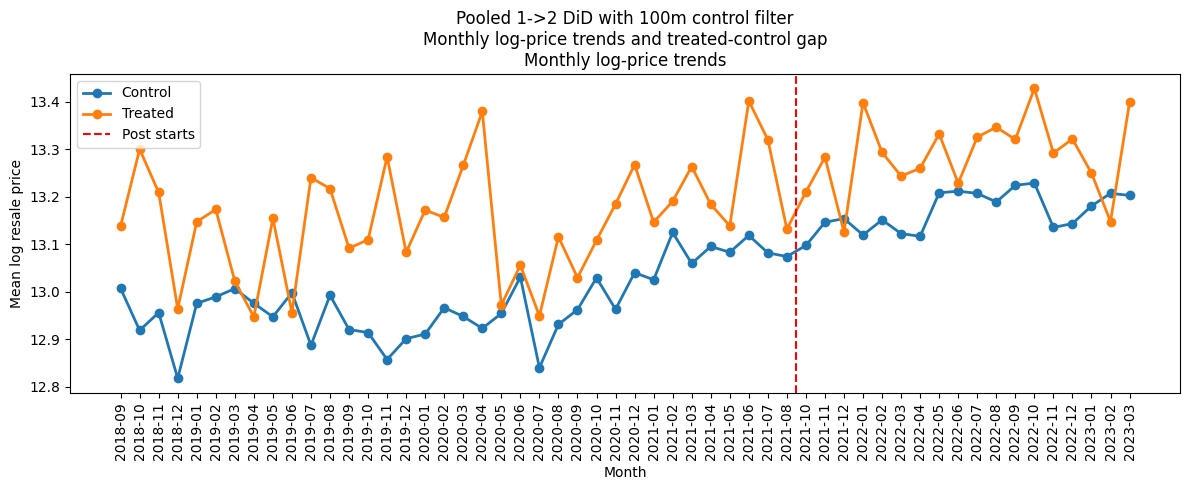

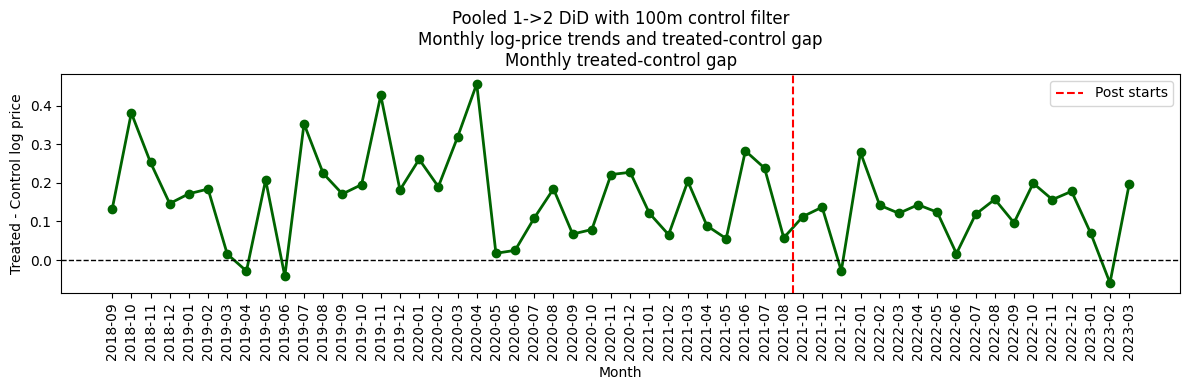

In [71]:
plot_monthly_log_price_and_gap(
    did_df_nc,
    title='Pooled 1->2 DiD with 100m control filter\nMonthly log-price trends and treated-control gap'
)

### Alternative Support Screen

This branch applies a slightly different school-level support rule: treated observations must still clear a minimum count threshold, while controls must outnumber treated observations in both periods.

It functions as an additional feasibility screen for the pooled 1-to-2 sample rather than a separate headline result.
        

In [57]:
did_df = did_12x_new.copy()
did_df['initial_school'] = did_df['pre_good_school_names_0_1km'].astype(str).str.strip()

support = (
    did_df
    .groupby(['initial_school', 'treated', 'period'])
    .size()
    .unstack(['treated', 'period'], fill_value=0)
)

support.columns = [f't{t}_{p}' for t, p in support.columns]
for col in ['t1_pre', 't1_post', 't0_pre', 't0_post']:
    if col not in support.columns:
        support[col] = 0

min_treated = 10

keep_schools = support[
    (support['t1_pre'] >= min_treated) &
    (support['t1_post'] >= min_treated) &
    (support['t0_pre'] > support['t1_pre']) &
    (support['t0_post'] > support['t1_post'])
].index

did_12x_filtered = did_df[did_df['initial_school'].isin(keep_schools)].copy()

print("Schools kept:", len(keep_schools))
print(support.loc[keep_schools].sort_values(['t1_pre', 't1_post']))
print(did_12x_filtered.groupby(['treated', 'period']).size())


Schools kept: 6
                                     t0_post  t0_pre  t1_post  t1_pre
initial_school                                                       
CHONGFU SCHOOL                           672    1318       25      32
PEI HWA PRESBYTERIAN PRIMARY SCHOOL       34      93       12      34
CHIJ PRIMARY (TOA PAYOH)                 385     538       31      41
AI TONG SCHOOL                            56      88       33      65
CATHOLIC HIGH SCHOOL                     217     440       58     126
PEI CHUN PUBLIC SCHOOL                   364     737       87     167
treated  period
0        post      1728
         pre       3214
1        post       246
         pre        465
dtype: int64


### Nearby-Control Robustness Check

This robustness check keeps all treated observations but restricts controls to flats that are geographically close to the nearest treated flat.

The goal is to tighten local comparability by comparing treated units against nearby control units in the same broad housing market. In the current code, the active filter is `control_radius_m = 200`, even though some legacy comments and plot titles still refer to a `100m` filter from an earlier iteration.

This cell therefore reads as a local-control robustness exercise, not as the primary pooled specification above.
        

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import statsmodels.formula.api as smf
from shapely import wkt

# -----------------------------------------------------------------------------
# Plain DiD: pooled 1->2 setup
# Controls are 1->1 units within 100m of the nearest treated flat
# GeoPandas distance is valid because geometries are in EPSG:3414 (meters)
# -----------------------------------------------------------------------------

control_radius_m = 200

did_df_nc = did_12x_new.copy()
did_df_nc['geometry'] = did_df_nc['geometry'].apply(
    lambda g: wkt.loads(g) if isinstance(g, str) else g
)

did_gdf_nc = gpd.GeoDataFrame(did_df_nc, geometry='geometry', crs='EPSG:3414')
treated_gdf = did_gdf_nc[did_gdf_nc['treated'] == 1].copy()
control_gdf = did_gdf_nc[did_gdf_nc['treated'] == 0].copy()

if treated_gdf.empty or control_gdf.empty:
    raise ValueError('Need both treated and control observations before applying the 100m filter.')

treated_sites = treated_gdf[['geometry']].copy()
treated_sites['x_coord'] = treated_sites.geometry.x
treated_sites['y_coord'] = treated_sites.geometry.y
treated_sites = treated_sites.drop_duplicates(subset=['x_coord', 'y_coord']).reset_index(drop=True)
treated_sites['treated_site_id'] = np.arange(len(treated_sites))
treated_sites = gpd.GeoDataFrame(treated_sites, geometry='geometry', crs=did_gdf_nc.crs)

control_join = gpd.sjoin_nearest(
    control_gdf,
    treated_sites[['treated_site_id', 'geometry']],
    how='left',
    distance_col='dist_to_treated_m'
)

control_keep = control_join[
    control_join['dist_to_treated_m'] <= control_radius_m
].copy()
if 'index_right' in control_keep.columns:
    control_keep = control_keep.drop(columns=['index_right'])

did_df_nc = pd.concat([treated_gdf, control_keep], ignore_index=True)
did_df_nc['log_price'] = np.log(did_df_nc['resale_price'])
did_df_nc['year_quarter'] = did_df_nc['Date'].dt.to_period('Q').astype(str)
did_df_nc['flat_type_clean'] = clean_label(did_df_nc['flat_type'])
did_df_nc['unit_id']=did_df_nc['flat_type_clean']+'_'+did_df_nc['pre_good_school_names_0_1km']
print('Controls kept within 100m of nearest treated flat:')
print(control_keep.shape[0])
print('\nSample size by treated / period after 100m GeoPandas filter:')
print(did_df_nc.groupby(['treated', 'period']).size())
print('\nDistance to nearest treated flat (meters), controls only:')
print(control_keep['dist_to_treated_m'].describe())

did_model_nc = smf.ols(
    """
    log_price ~ treated * post
    + C(unit_id)
    + C(year_quarter)
    + floor_area_sqm
    + remaining_lease
    + C(flat_model)
    + C(storey_range)
    """
    ,data=did_df_nc
).fit(
    cov_type='cluster',
    cov_kwds={'groups': did_df_nc['unit_id']}
)

print('\nRegular pooled 1->2 DiD ATT (treated:post):')
print(did_model_nc.params['treated:post'])
print(did_model_nc.bse['treated:post'])
print(did_model_nc.pvalues['treated:post'])
print(did_model_nc.summary())


Controls kept within 100m of nearest treated flat:
1548

Sample size by treated / period after 100m GeoPandas filter:
treated  period
0        post       504
         pre       1044
1        post       363
         pre        716
dtype: int64

Distance to nearest treated flat (meters), controls only:
count    1548.000000
mean      130.509801
std        46.862097
min        37.671413
25%        83.871827
50%       138.697175
75%       173.800914
max       198.408059
Name: dist_to_treated_m, dtype: float64

Regular pooled 1->2 DiD ATT (treated:post):
0.0023561486435737244
0.00886080087329624
0.7903108629551121
                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                 1.127e+12
Date:                Sat, 04 Apr 2026   Prob (F-statistic):         

c:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 89, but rank is 35
  warnings.warn('covariance of constraints does not have full '


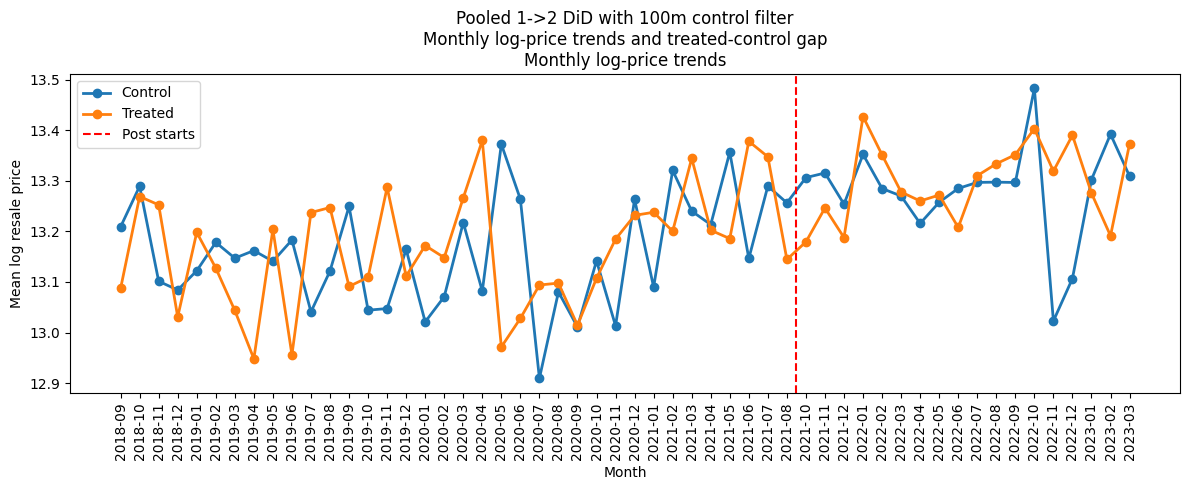

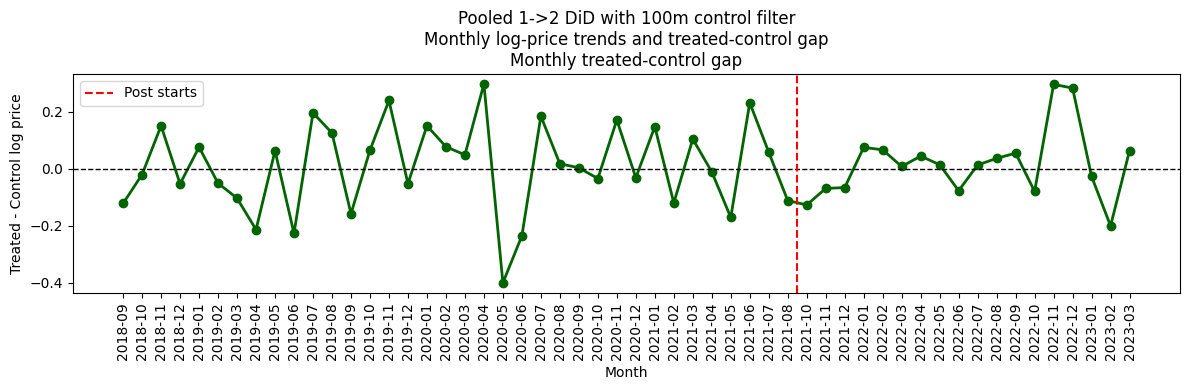

In [43]:
# Check for pre trends by plotting monthly log-price trends and treated-control gap
plot_monthly_log_price_and_gap(
    did_df_nc,
    title='Pooled 1->2 DiD with 100m control filter\nMonthly log-price trends and treated-control gap'
)

## Archival Clustering And Synthetic DiD Branch

The remaining cells explore a more elaborate clustered matching and Synthetic DiD workflow. They are kept because they document earlier robustness work and may still be useful for future extensions.

They are not the notebook's main pooled specification. For a first read, the standard pooled DiD section above is the part to focus on.
        

## Clustering logic (unused)

The pooled main specification is the standard DiD workflow above.
This clustering-based SDID path is kept only as archival / reference material and is not used for the pooled results.


In [74]:
did_01x_new[did_01x_new['delta_good_schools_0_1km']==0]['pre_num_good_schools_1_2km'].value_counts()

pre_num_good_schools_1_2km
0    23966
1    12662
2     4948
3     1531
4      107
Name: count, dtype: int64

### Period Trimming Helper

Synthetic DiD requires a panel with support in both treatment arms across time. This helper removes quarters that do not have enough treated and control units before balancing, so later SDID fits are not built on mechanically unsupported periods.
        

In [10]:
def trim_periods_before_balancing(
    panel_df,
    unit_col='unit_id',
    time_col='year_quarter',
    treated_col='treated',
    min_treated_units_per_period=1,
    min_control_units_per_period=1,
):
    period_support = (
        panel_df
        .groupby([time_col, treated_col])[unit_col]
        .nunique()
        .unstack(fill_value=0)
        .rename(columns={0: 'control_units', 1: 'treated_units'})
        .sort_index()
    )

    for col in ['control_units', 'treated_units']:
        if col not in period_support.columns:
            period_support[col] = 0

    keep_periods = period_support.index[
        (period_support['treated_units'] >= min_treated_units_per_period) &
        (period_support['control_units'] >= min_control_units_per_period)
    ].tolist()

    trimmed = panel_df[panel_df[time_col].isin(keep_periods)].copy()

    return {
        'panel_df': trimmed,
        'period_support': period_support.reset_index(),
        'keep_periods': keep_periods,
    }

### First Clustering Configuration

This block builds clustered local comparison groups and inspects pre-period treated-versus-control gaps within those groups.

The emphasis here is diagnostic: the code checks whether the clustering scheme creates groups with reasonable overlap before attempting a pooled SDID fit.
        

In [209]:
cluster_eps_m=1400
control_radius_m=500

built = build_clustered_sdid_objects(
    base_df=did_01x_new,
    cluster_eps_m=cluster_eps_m,
    control_radius_m=control_radius_m,
    min_control_obs=13,
    min_treated_obs=10,
)

did_local = built['did_local']
cluster_summary = built['cluster_summary']
sdid_panel_pool = built['sdid_panel']
covariate_cols_pool = built['covariate_cols']
post_periods_pool = built['post_periods']

pre_means = (
    did_local[did_local['period'] == 'pre']
    .groupby(['local_group_id', 'treated'])['log_price']
    .mean()
    .unstack()
    .rename(columns={0: 'control_mean', 1: 'treated_mean'})
)
pre_means['gap'] = pre_means['treated_mean'] - pre_means['control_mean']

print(pre_means.sort_values('gap'))
print(f"\nClusters where treated < control pre-period: {(pre_means['gap'] < 0).sum()} / {len(pre_means)}")
print(f"Mean within-cluster gap: {pre_means['gap'].mean():.4f}")

treated         control_mean  treated_mean       gap
local_group_id                                      
cluster_13         13.329090     12.360847 -0.968244
cluster_1          12.813897     12.557005 -0.256892
cluster_18         13.044968     12.917426 -0.127541
cluster_6          12.860983     12.805646 -0.055337
cluster_3          12.978972     12.937540 -0.041432
cluster_12         12.799257     12.768032 -0.031226
cluster_8          12.798106     12.767534 -0.030572
cluster_16         12.643430     12.615778 -0.027652
cluster_5          12.868661     12.860153 -0.008509
cluster_15         12.837401     12.835189 -0.002212
cluster_9          13.077815     13.091572  0.013756
cluster_0          12.983985     13.004912  0.020927
cluster_2          13.008207     13.051095  0.042888
cluster_4          12.860121     12.921078  0.060957
cluster_10         13.058969     13.132867  0.073898
cluster_7          12.922683     13.095685  0.173002
cluster_17         12.812427     13.025599  0.

In [189]:
balance_cols = [
    'floor_area_sqm', 'remaining_lease',
    'num_unique_mrt_lines', 'num_nearby_malls',
    'pre_num_good_schools_1_2km', 'pre_num_normal_schools_0_1km'
]

balance = (
    did_local[did_local['period'] == 'pre']
    .groupby('treated')[balance_cols]
    .mean()
    .T
    .rename(columns={0: 'control', 1: 'treated'})
    .assign(diff=lambda d: d['treated'] - d['control'],
            pct_diff=lambda d: (d['treated'] - d['control']) / d['control'] * 100)
)
print(balance.round(3))

treated                       control  treated    diff  pct_diff
floor_area_sqm                 93.521   92.774  -0.748    -0.799
remaining_lease               847.243  822.403 -24.839    -2.932
num_unique_mrt_lines            1.156    1.182   0.025     2.172
num_nearby_malls                1.364    1.334  -0.030    -2.191
pre_num_good_schools_1_2km      1.456    1.669   0.214    14.687
pre_num_normal_schools_0_1km    2.719    2.472  -0.247    -9.080


In [190]:
quarterly_gap = (
    did_local
    .groupby(['local_group_id', 'year_quarter', 'treated'])['log_price']
    .mean()
    .unstack('treated')
    .rename(columns={0: 'control', 1: 'treated'})
    .assign(gap=lambda d: d['treated'] - d['control'])
    .reset_index()
)

# Pre vs post gap by cluster
print(
    quarterly_gap
    .assign(period=lambda d: d['year_quarter'].ge('2021Q4').map({True: 'post', False: 'pre'}))
    .groupby(['local_group_id', 'period'])['gap']
    .mean()
    .unstack()
    .assign(delta=lambda d: d['post'] - d['pre'])
    .sort_values('delta', ascending=False)
)

period              post       pre     delta
local_group_id                              
cluster_8       0.438358  0.254494  0.183864
cluster_3      -0.052920 -0.153656  0.100737
cluster_7       0.009510 -0.086123  0.095633
cluster_1      -0.143782 -0.190890  0.047108
cluster_2      -0.074351 -0.086047  0.011696
cluster_9       0.098251  0.088032  0.010218
cluster_5       0.020373  0.024902 -0.004529
cluster_6       0.020347  0.027389 -0.007043
cluster_10      0.020844  0.030254 -0.009411
cluster_4      -0.141316 -0.119479 -0.021837
cluster_0      -0.028590  0.024397 -0.052987


In [203]:
# Merge pre-period gap back onto cluster_summary
cluster_check = cluster_summary.merge(
    pre_means[['gap']].rename(columns={'gap': 'pre_period_gap'}),
    on='local_group_id',
    how='left'
)

print(
    cluster_check[['local_group_id', 'treated_obs', 'control_obs', 'pre_period_gap']]
    .sort_values('pre_period_gap')
)

treated local_group_id  treated_obs  control_obs  pre_period_gap
1            cluster_1          270         1563       -0.213697
4            cluster_3          128          516       -0.149928
5            cluster_4          122         1264       -0.090771
3            cluster_2          249          975       -0.076580
8            cluster_7           17          132       -0.058763
0            cluster_0          620         4397        0.017859
10           cluster_9           47          835        0.021178
6            cluster_5          361         2604        0.021540
2           cluster_10          235         1972        0.031072
7            cluster_6           67          601        0.104880
9            cluster_8           46           94        0.262932


In [212]:
c1 = did_local[did_local['local_group_id'] == 'cluster_13'].copy()

# Flat type mix
print("Flat type distribution:")
print(c1.groupby(['treated', 'flat_type']).size().unstack(fill_value=0))

# Key observables balance
balance_cols = [
    'floor_area_sqm', 'remaining_lease',
    'num_unique_mrt_lines', 'num_nearby_malls',
    'pre_num_good_schools_1_2km', 'pre_num_normal_schools_0_1km',
]
print("\nObservable balance:")
print(
    c1[c1['period'] == 'pre']
    .groupby('treated')[balance_cols]
    .mean()
    .T
    .assign(diff=lambda d: d[1] - d[0])
    .round(3)
)

# Where are these units geographically
print("\nTreated towns in cluster_1:")
print(c1[c1['treated'] == 1]['town'].value_counts())
print("\nControl towns in cluster_1:")
print(c1[c1['treated'] == 0]['town'].value_counts())

# print good schools in cluster 1
print("\nGood schools in cluster_1:")
print(c1['pre_good_school_names_0_1km'].explode().value_counts())

Flat type distribution:
flat_type  2 ROOM  3 ROOM  4 ROOM  5 ROOM  EXECUTIVE
treated                                             
0               0      29       9      16         11
1              43      16       0       0          0

Observable balance:
treated                             0        1     diff
floor_area_sqm                118.359   52.143  -66.216
remaining_lease               747.641  585.738 -161.903
num_unique_mrt_lines            1.000    1.000    0.000
num_nearby_malls                0.000    0.000    0.000
pre_num_good_schools_1_2km      1.000    1.000    0.000
pre_num_normal_schools_0_1km    0.000    0.000    0.000

Treated towns in cluster_1:
town
KALLANG/WHAMPOA    59
Name: count, dtype: int64

Control towns in cluster_1:
town
KALLANG/WHAMPOA    65
Name: count, dtype: int64

Good schools in cluster_1:
Series([], Name: count, dtype: int64)


In [193]:
# Check which clusters are included in the SDID panel after balancing
print("\nClusters included in SDID panel after balancing:")
print(
    sdid_panel_pool['unit_id']
    .str.extract(r'^(cluster_\d+)_T\d+_g01_\d+_ft_.*$')[0]
    .value_counts()
)


Clusters included in SDID panel after balancing:
0
cluster_0     190
cluster_5     171
cluster_10     95
cluster_2      95
cluster_1      95
cluster_3      57
cluster_4      57
cluster_6      57
cluster_9      38
Name: count, dtype: int64


In [194]:
# Before balance_panel, how many quarters does each treated unit_id cover?
pre_balance = (
    did_local
    .groupby(['unit_id', 'treated'])['year_quarter']
    .nunique()
    .reset_index()
    .rename(columns={'year_quarter': 'n_quarters'})
)

print(pre_balance[pre_balance['treated'] == 1].sort_values('n_quarters'))

                              unit_id  treated  n_quarters
17    cluster_0_T1_g01_0_ft_EXECUTIVE        1           1
84       cluster_4_T1_g01_0_ft_2_ROOM        1           1
73       cluster_3_T1_g01_0_ft_4_ROOM        1           3
33      cluster_10_T1_g01_0_ft_2_ROOM        1           3
116      cluster_7_T1_g01_0_ft_3_ROOM        1           4
108      cluster_6_T1_g01_0_ft_2_ROOM        1           4
38      cluster_10_T1_g01_1_ft_4_ROOM        1           5
58       cluster_2_T1_g01_0_ft_3_ROOM        1           5
118      cluster_7_T1_g01_0_ft_5_ROOM        1           5
117      cluster_7_T1_g01_0_ft_4_ROOM        1           6
132      cluster_9_T1_g01_0_ft_3_ROOM        1           6
134   cluster_9_T1_g01_0_ft_EXECUTIVE        1           8
88    cluster_4_T1_g01_0_ft_EXECUTIVE        1           8
22    cluster_0_T1_g01_1_ft_EXECUTIVE        1           9
52    cluster_1_T1_g01_0_ft_EXECUTIVE        1          10
110      cluster_6_T1_g01_0_ft_4_ROOM        1          

In [195]:
print("Number of local groups:", did_local['local_group_id'].nunique())
print("\nCluster support:")
display(
    cluster_summary
    .set_index('local_group_id')[['control_obs', 'treated_obs']]
    .sort_index()
)
sdid_panel_excl1 = sdid_panel_pool[
    ~sdid_panel_pool['unit_id'].str.contains('cluster_1')  # adjust if unit_id encodes differently
].copy()

print("Balanced pooled SDID unit-panels by arm:")
print(sdid_panel_excl1[['unit_id', 'treated']].drop_duplicates()['treated'].value_counts())

print("\nBalanced pooled SDID units total:")
print(sdid_panel_excl1['unit_id'].nunique())

print("\nClusters represented in pooled sample:")
print(did_local[['local_group_id']].drop_duplicates().shape[0])
sdid_pool = SyntheticDiD(
    seed=42,
    variance_method='placebo',
    n_bootstrap=200
)

sdid_results_pool = sdid_pool.fit(
    sdid_panel_pool,
    outcome='log_price',
    treatment='treated',
    unit='unit_id',
    time='year_quarter',
    post_periods=post_periods_pool,
    covariates=covariate_cols_pool
)

print(sdid_results_pool.summary())
display(sdid_results_pool.get_unit_weights_df().head(20))
display(sdid_results_pool.get_time_weights_df().head(20))


Number of local groups: 11

Cluster support:


treated,control_obs,treated_obs
local_group_id,,
cluster_0,4397,620
cluster_1,1563,270
cluster_10,1972,235
cluster_2,975,249
cluster_3,516,128
cluster_4,1264,122
cluster_5,2604,361
cluster_6,601,67
cluster_7,132,17


Balanced pooled SDID unit-panels by arm:
treated
0    27
1     9
Name: count, dtype: int64

Balanced pooled SDID units total:
36

Clusters represented in pooled sample:
11
           Synthetic Difference-in-Differences Estimation Results          

Observations:                    874
Treated:                          10
Control:                          36
Pre-treatment periods:            13
Post-treatment periods:            6
Zeta (unit weights):          0.1183
Zeta (time weights):        0.000000
Noise level:                  0.0425
Pre-treatment fit (RMSE):     0.0151
Variance method:             placebo

---------------------------------------------------------------------------
Parameter           Estimate    Std. Err.     t-stat      P>|t|      
---------------------------------------------------------------------------
ATT                  -0.0089       0.0119     -0.748     0.4750      
---------------------------------------------------------------------------

95% Confide

c:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\.venv\Lib\site-packages\diff_diff\synthetic_did.py:539: UserWarning: Rank-deficient design matrix: dropping 1 of 97 columns (column 20). Coefficients for these columns are set to NA. This may indicate multicollinearity in your model specification.
  coeffs, residuals, _ = solve_ols(X_full, y, return_vcov=False)


,unit,weight
4,cluster_0_T0_g01_1_ft_4_ROOM,0.049190
18,cluster_2_T0_g01_0_ft_EXECUTIVE,0.047277
28,cluster_5_T0_g01_1_ft_3_ROOM,0.045871
8,cluster_10_T0_g01_0_ft_4_ROOM,0.044170
24,cluster_5_T0_g01_0_ft_3_ROOM,0.043691
29,cluster_5_T0_g01_1_ft_4_ROOM,0.040532
25,cluster_5_T0_g01_0_ft_4_ROOM,0.038394
10,cluster_10_T0_g01_1_ft_4_ROOM,0.037653
22,cluster_4_T0_g01_0_ft_5_ROOM,0.035789
15,cluster_1_T0_g01_1_ft_4_ROOM,0.034204


,period,weight
0,2018Q3,0.005857
1,2018Q4,0.000000
2,2019Q1,0.000000
3,2019Q2,0.000000
4,2019Q3,0.000000
5,2019Q4,0.000000
6,2020Q1,0.000000
7,2020Q2,0.046014
8,2020Q3,0.024557
9,2020Q4,0.227017


### Pooled Synthetic DiD Fit Under An Alternative Clustering Choice

This section reruns the clustered construction with a different pair of tuning parameters and then fits the pooled Synthetic DiD estimator.

The printed output summarises how many local groups survive, how many balanced unit panels remain, and the resulting SDID treatment effect plus model weights.
        

In [62]:
cluster_eps_m=1200
control_radius_m=900

built = build_clustered_sdid_objects(
    base_df=did_01x_new,
    cluster_eps_m=cluster_eps_m,
    control_radius_m=control_radius_m,
    min_control_obs=13,
    min_treated_obs=10,
)

did_local = built['did_local']
cluster_summary = built['cluster_summary']
sdid_panel_pool = built['sdid_panel']
covariate_cols_pool = built['covariate_cols']
post_periods_pool = built['post_periods']

print("Number of local groups:", did_local['local_group_id'].nunique())
print("\nCluster support:")
display(
    cluster_summary
    .set_index('local_group_id')[['control_obs', 'treated_obs']]
    .sort_index()
)

print("Balanced pooled SDID unit-panels by arm:")
print(sdid_panel_pool[['unit_id', 'treated']].drop_duplicates()['treated'].value_counts())

print("\nBalanced pooled SDID units total:")
print(sdid_panel_pool['unit_id'].nunique())

print("\nClusters represented in pooled sample:")
print(did_local[['local_group_id']].drop_duplicates().shape[0])
sdid_pool = SyntheticDiD(
    seed=42,
    variance_method='placebo',
    n_bootstrap=200
)

sdid_results_pool = sdid_pool.fit(
    sdid_panel_pool,
    outcome='log_price',
    treatment='treated',
    unit='unit_id',
    time='year_quarter',
    post_periods=post_periods_pool,
    covariates=covariate_cols_pool
)

print(sdid_results_pool.summary())
display(sdid_results_pool.get_unit_weights_df().head(20))
display(sdid_results_pool.get_time_weights_df().head(20))


Number of local groups: 22

Cluster support:


treated,control_obs,treated_obs
local_group_id,,
cluster_0,4540,620
cluster_1,1161,178
cluster_10,249,17
cluster_11,94,46
cluster_12,218,36
cluster_13,311,19
cluster_14,65,59
cluster_15,21,10
cluster_16,1369,131


Balanced pooled SDID unit-panels by arm:
treated
0    42
1     7
Name: count, dtype: int64

Balanced pooled SDID units total:
49

Clusters represented in pooled sample:
22


c:\Users\rob-l\Documents\NUS\Y4S2\DSA4264\DSA4264-Project\.venv\Lib\site-packages\diff_diff\synthetic_did.py:539: UserWarning: Rank-deficient design matrix: dropping 1 of 99 columns (column 19). Coefficients for these columns are set to NA. This may indicate multicollinearity in your model specification.
  coeffs, residuals, _ = solve_ols(X_full, y, return_vcov=False)


           Synthetic Difference-in-Differences Estimation Results          

Observations:                    931
Treated:                           7
Control:                          42
Pre-treatment periods:            13
Post-treatment periods:            6
Zeta (unit weights):          0.1172
Zeta (time weights):        0.000000
Noise level:                  0.0461
Pre-treatment fit (RMSE):     0.0094
Variance method:             placebo

---------------------------------------------------------------------------
Parameter           Estimate    Std. Err.     t-stat      P>|t|      
---------------------------------------------------------------------------
ATT                  -0.0113       0.0115     -0.982     0.3650      
---------------------------------------------------------------------------

95% Confidence Interval: [-0.0338, 0.0112]

---------------------------------------------------------------------------
                    Top Unit Weights (Synthetic Control)       

,unit,weight
13,cluster_18_T0_ft_4_ROOM,0.040055
30,cluster_6_T0_ft_5_ROOM,0.038057
11,cluster_16_T0_ft_EXECUTIVE,0.035820
35,cluster_8_T0_ft_3_ROOM,0.034134
32,cluster_7_T0_ft_3_ROOM,0.033354
38,cluster_8_T0_ft_EXECUTIVE,0.032212
25,cluster_3_T0_ft_EXECUTIVE,0.031412
37,cluster_8_T0_ft_5_ROOM,0.031241
36,cluster_8_T0_ft_4_ROOM,0.030382
5,cluster_12_T0_ft_3_ROOM,0.030194


,period,weight
0,2018Q3,0.000000
1,2018Q4,0.000000
2,2019Q1,0.000000
3,2019Q2,0.000000
4,2019Q3,0.000000
5,2019Q4,0.000000
6,2020Q1,0.000000
7,2020Q2,0.150222
8,2020Q3,0.007756
9,2020Q4,0.000000


### Placebo And Fit-Diagnostic Utilities

These helpers wrap the SDID estimator so the notebook can run placebo timing tests, placebo group assignments, and simple pre-fit quality flags. The intent is to stress-test the clustered SDID branch rather than replace the simpler pooled DiD benchmark.
        

In [63]:
import numpy as np
import pandas as pd
import warnings
from diff_diff import SyntheticDiD

def _sdid_fit_with_flags(
    panel_df,
    post_periods,
    covariates,
    outcome='log_price',
    treatment='treated',
    unit='unit_id',
    time='year_quarter',
    seed=42,
    variance_method='placebo',
    n_bootstrap=200,
):
    sdid = SyntheticDiD(
        seed=seed,
        variance_method=variance_method,
        n_bootstrap=n_bootstrap,
    )

    pre_periods = sorted(panel_df.loc[~panel_df[time].isin(post_periods), time].unique())

    with warnings.catch_warnings(record=True) as caught_warnings:
        warnings.simplefilter("always")
        res = sdid.fit(
            panel_df,
            outcome=outcome,
            treatment=treatment,
            unit=unit,
            time=time,
            post_periods=post_periods,
            covariates=covariates,
        )

    treated_pre = panel_df[
        (panel_df[treatment] == 1) &
        (panel_df[time].isin(pre_periods))
    ][outcome]

    treated_pre_sd = treated_pre.std()
    pre_fit_ratio = (
        res.pre_treatment_fit / treated_pre_sd
        if pd.notna(treated_pre_sd) and treated_pre_sd > 0
        else np.nan
    )
    poor_pre_fit = bool(pre_fit_ratio > 1) if pd.notna(pre_fit_ratio) else np.nan
    poor_pre_fit = poor_pre_fit or any(
        "Pre-treatment fit is poor" in str(w.message)
        for w in caught_warnings
    )

    return {
        "results": res,
        "att": res.att,
        "se": res.se,
        "p_value": res.p_value,
        "pre_fit_rmse": res.pre_treatment_fit,
        "pre_fit_ratio": pre_fit_ratio,
        "poor_pre_fit": poor_pre_fit,
    }


def sdid_placebo_timing_test(
    panel_df,
    actual_post_start='2021Q4',
    fake_post_start='2020Q4',
    covariates=None,
    outcome='log_price',
    treatment='treated',
    unit='unit_id',
    time='year_quarter',
    seed=42,
    variance_method='placebo',
    n_bootstrap=200,
):
    placebo_df = panel_df[panel_df[time] < actual_post_start].copy()

    fake_post_periods = sorted(
        placebo_df.loc[placebo_df[time] >= fake_post_start, time].unique()
    )

    if len(fake_post_periods) == 0:
        raise ValueError("No fake post periods found. Pick an earlier fake_post_start.")

    out = _sdid_fit_with_flags(
        placebo_df,
        post_periods=fake_post_periods,
        covariates=covariates,
        outcome=outcome,
        treatment=treatment,
        unit=unit,
        time=time,
        seed=seed,
        variance_method=variance_method,
        n_bootstrap=n_bootstrap,
    )

    return {
        "test_type": "fake_timing",
        "fake_post_start": fake_post_start,
        "n_obs": len(placebo_df),
        **{k: v for k, v in out.items() if k != "results"},
        "results": out["results"],
    }


def sdid_placebo_group_test(
    panel_df,
    post_periods,
    covariates=None,
    outcome='log_price',
    treatment='treated',
    unit='unit_id',
    time='year_quarter',
    n_fake_treated=None,
    seed=42,
    variance_method='placebo',
    n_bootstrap=200,
):
    rng = np.random.default_rng(seed)

    controls_only = panel_df[panel_df[treatment] == 0].copy()
    control_units = np.array(sorted(controls_only[unit].unique()))

    if n_fake_treated is None:
        n_fake_treated = int(panel_df.loc[panel_df[treatment] == 1, unit].nunique())

    if n_fake_treated <= 0 or n_fake_treated >= len(control_units):
        raise ValueError("n_fake_treated must be between 1 and number of control units - 1.")

    fake_treated_units = rng.choice(control_units, size=n_fake_treated, replace=False)

    placebo_df = controls_only.copy()
    placebo_df["_fake_treated"] = placebo_df[unit].isin(fake_treated_units).astype(int)

    out = _sdid_fit_with_flags(
        placebo_df,
        post_periods=post_periods,
        covariates=covariates,
        outcome=outcome,
        treatment="_fake_treated",
        unit=unit,
        time=time,
        seed=seed,
        variance_method=variance_method,
        n_bootstrap=n_bootstrap,
    )

    return {
        "test_type": "fake_group",
        "n_fake_treated": n_fake_treated,
        "fake_treated_units": list(fake_treated_units),
        "n_obs": len(placebo_df),
        **{k: v for k, v in out.items() if k != "results"},
        "results": out["results"],
    }


In [64]:
timing_placebo = sdid_placebo_timing_test(
    panel_df=sdid_panel_pool,
    actual_post_start='2021Q4',
    fake_post_start='2020Q4',   # choose a clearly pre-treatment date
    covariates=covariate_cols_pool,
    outcome='log_price',
    treatment='treated',
    unit='unit_id',
    time='year_quarter',
    seed=42,
    variance_method='placebo',
    n_bootstrap=200,
)

print(pd.Series({k: v for k, v in timing_placebo.items() if k not in ['results', 'fake_treated_units']}))
print(timing_placebo["results"].summary())


test_type          fake_timing
fake_post_start         2020Q4
n_obs                      637
att                  -0.001733
se                    0.014915
p_value                  0.915
pre_fit_rmse          0.008167
pre_fit_ratio          0.02566
poor_pre_fit             False
dtype: object
           Synthetic Difference-in-Differences Estimation Results          

Observations:                    637
Treated:                           7
Control:                          42
Pre-treatment periods:             9
Post-treatment periods:            4
Zeta (unit weights):          0.1108
Zeta (time weights):        0.000000
Noise level:                  0.0482
Pre-treatment fit (RMSE):     0.0082
Variance method:             placebo

---------------------------------------------------------------------------
Parameter           Estimate    Std. Err.     t-stat      P>|t|      
---------------------------------------------------------------------------
ATT                  -0.0017       0.

In [65]:
group_placebo = sdid_placebo_group_test(
    panel_df=sdid_panel_pool,
    post_periods=post_periods_pool,
    covariates=covariate_cols_pool,
    outcome='log_price',
    treatment='treated',
    unit='unit_id',
    time='year_quarter',
    n_fake_treated=None,  # defaults to same number as real treated units
    seed=42,
    variance_method='placebo',
    n_bootstrap=200,
)

print(pd.Series({k: v for k, v in group_placebo.items() if k not in ['results', 'fake_treated_units']}))
print(group_placebo["results"].summary())


test_type         fake_group
n_fake_treated             7
n_obs                    798
att                -0.026727
se                  0.009717
p_value             0.004975
pre_fit_rmse        0.011672
pre_fit_ratio       0.024722
poor_pre_fit            True
dtype: object
           Synthetic Difference-in-Differences Estimation Results          

Observations:                    798
Treated:                           7
Control:                          35
Pre-treatment periods:            13
Post-treatment periods:            6
Zeta (unit weights):          0.1107
Zeta (time weights):        0.000000
Noise level:                  0.0435
Pre-treatment fit (RMSE):     0.0117
Variance method:             placebo

---------------------------------------------------------------------------
Parameter           Estimate    Std. Err.     t-stat      P>|t|      
---------------------------------------------------------------------------
ATT                  -0.0267       0.0097     -2.750   

### Weighted-Path Visualisation For SDID

After fitting SDID, this plotting helper reconstructs the observed treated path and the model-weighted synthetic control path over time. The two charts are mainly interpretive diagnostics: they show pre-period fit and how the treated-minus-synthetic gap evolves after the post period begins.
        

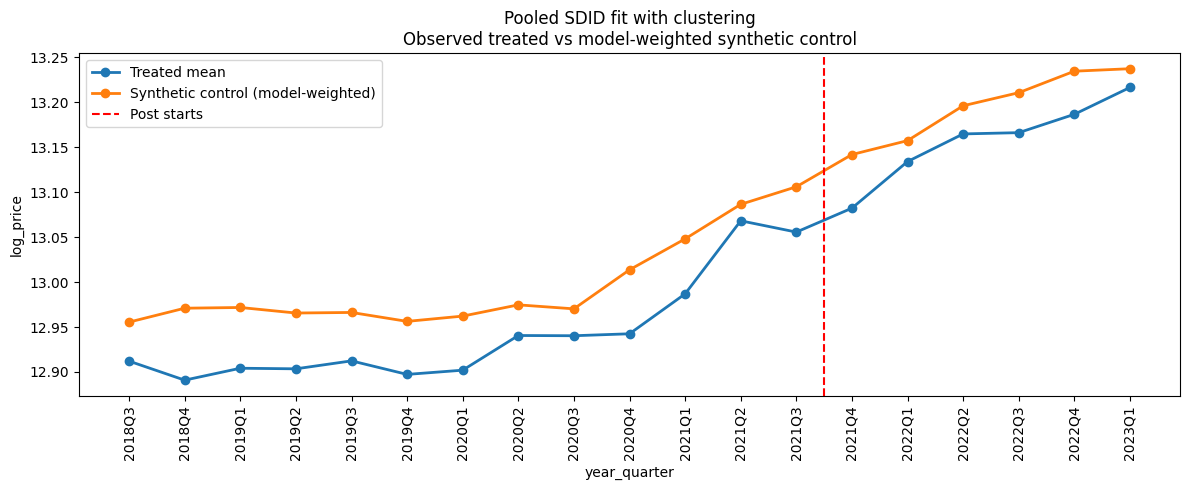

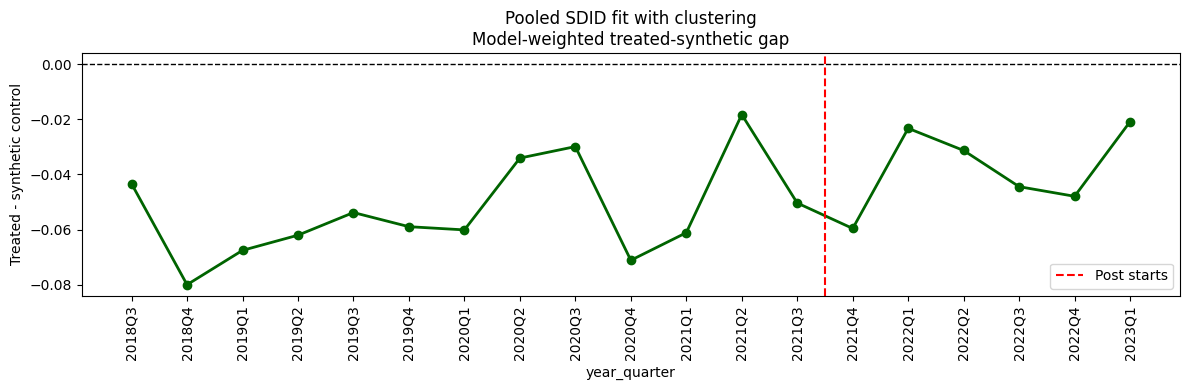

,year_quarter,treated_path,synthetic_path,gap
0,2018Q3,12.912070,12.955453,-0.043383
1,2018Q4,12.890931,12.970901,-0.079970
2,2019Q1,12.904177,12.971695,-0.067519
3,2019Q2,12.903524,12.965540,-0.062016
4,2019Q3,12.912364,12.966170,-0.053806
5,2019Q4,12.897322,12.956256,-0.058934
6,2020Q1,12.902012,12.962112,-0.060100
7,2020Q2,12.940554,12.974611,-0.034056
8,2020Q3,12.940296,12.970187,-0.029891
9,2020Q4,12.942464,13.013578,-0.071114


In [66]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_sdid_weighted_paths(
    panel_df,
    results,
    unit_col='unit_id',
    time_col='year_quarter',
    outcome_col='log_price',
    treated_col='treated',
    title='SyntheticDiD fit',
    normalize_within_period=True,
    add_intercept=True,
):
    # --- 1) unit weights from the fitted model ---
    control_weights = (
        pd.Series(results.unit_weights, name='weight')
        .rename_axis(unit_col)
        .reset_index()
    )

    # --- 2) treated path ---
    treated_path = (
        panel_df.loc[panel_df[treated_col] == 1]
        .groupby(time_col, sort=True)[outcome_col]
        .mean()
        .rename('treated_path')
    )

    # --- 3) weighted synthetic control path ---
    controls = (
        panel_df.loc[panel_df[treated_col] == 0, [unit_col, time_col, outcome_col]]
        .merge(control_weights, on=unit_col, how='inner')
        .copy()
    )

    if controls.empty:
        raise ValueError('No control units matched the SDID unit weights.')

    controls['weighted_outcome'] = controls[outcome_col] * controls['weight']

    synthetic_path = (
        controls.groupby(time_col, sort=True)
        .agg(
            weighted_outcome=('weighted_outcome', 'sum'),
            weight_sum=('weight', 'sum'),
        )
    )

    if normalize_within_period:
        # Good for unbalanced panels / missing control observations
        synthetic_path['synthetic_path'] = (
            synthetic_path['weighted_outcome'] / synthetic_path['weight_sum']
        )
    else:
        # Use raw weighted sum if you know weights already sum to 1
        synthetic_path['synthetic_path'] = synthetic_path['weighted_outcome']

    # --- 4) add SDID intercept/offset if present ---
    intercept = 0.0
    if add_intercept:
        for attr in ['intercept', 'alpha', 'bias', 'offset']:
            if hasattr(results, attr):
                intercept = getattr(results, attr)
                if intercept is not None:
                    break
        else:
            intercept = 0.0

    synthetic_path['synthetic_path'] = synthetic_path['synthetic_path'] + intercept

    # --- 5) combine for plotting ---
    plot_df = (
        pd.concat(
            [treated_path, synthetic_path['synthetic_path']],
            axis=1,
        )
        .reset_index()
        .sort_values(time_col)
        .reset_index(drop=True)
    )

    plot_df['gap'] = plot_df['treated_path'] - plot_df['synthetic_path']

    periods = plot_df[time_col].tolist()
    xpos = list(range(len(periods)))

    boundary_period = results.post_periods[0] if getattr(results, 'post_periods', None) else None
    boundary = periods.index(boundary_period) - 0.5 if boundary_period in periods else None

    # --- 6) main path plot ---
    plt.figure(figsize=(12, 5))
    plt.plot(xpos, plot_df['treated_path'], marker='o', linewidth=2, label='Treated mean')
    plt.plot(
        xpos,
        plot_df['synthetic_path'],
        marker='o',
        linewidth=2,
        label='Synthetic control (model-weighted)'
    )
    if boundary is not None:
        plt.axvline(boundary, color='red', linestyle='--', linewidth=1.5, label='Post starts')

    plt.xticks(xpos, periods, rotation=90)
    plt.xlabel(time_col)
    plt.ylabel(outcome_col)
    plt.title(f'{title}\nObserved treated vs model-weighted synthetic control')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- 7) gap plot ---
    plt.figure(figsize=(12, 4))
    plt.plot(xpos, plot_df['gap'], marker='o', linewidth=2, color='darkgreen')
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    if boundary is not None:
        plt.axvline(boundary, color='red', linestyle='--', linewidth=1.5, label='Post starts')

    plt.xticks(xpos, periods, rotation=90)
    plt.xlabel(time_col)
    plt.ylabel('Treated - synthetic control')
    plt.title(f'{title}\nModel-weighted treated-synthetic gap')
    if boundary is not None:
        plt.legend()
    plt.tight_layout()
    plt.show()

    return plot_df

plot_sdid_weighted_paths(
    panel_df=sdid_panel_pool,
    results=sdid_results_pool,
    unit_col='unit_id',
    time_col='year_quarter',
    outcome_col='log_price',
    treated_col='treated',
    title='Pooled SDID fit with clustering',
    normalize_within_period=True,
    add_intercept=True,
)

### Reference Implementation For Clustered SDID Evaluation

The final long helper block packages the clustered SDID workflow into a reusable evaluation function. It records sample attrition, fit warnings, and summary diagnostics for different clustering parameter choices.

This is retained as notebook infrastructure for experimentation rather than part of the final pooled readout.
        

In [83]:
# UNUSED: clustering-based SDID diagnostic retained only for reference.
# The pooled main specification in this notebook is the plain DiD workflow above.

from sklearn.cluster import DBSCAN
from diff_diff import SyntheticDiD
from diff_diff.prep import balance_panel
from shapely import wkt
import geopandas as gpd
import pandas as pd
import numpy as np
import warnings


def run_clustered_sdid_eval(
    base_df,
    cluster_eps_m,
    control_radius_m,
    min_treated_obs=10,
    min_control_obs=10,
    min_treated_units_per_period=1,
    min_control_units_per_period=1,
    variance_method='placebo',
    n_bootstrap=200,
    post_start='2021Q4',
):
    built = build_clustered_sdid_objects(
        base_df=base_df,
        cluster_eps_m=cluster_eps_m,
        control_radius_m=control_radius_m,
        min_treated_obs=min_treated_obs,
        min_control_obs=min_control_obs,
        min_treated_units_per_period=min_treated_units_per_period,
        min_control_units_per_period=min_control_units_per_period,
        post_start=post_start,
    )

    did_local = built['did_local']
    cluster_summary = built['cluster_summary']
    sdid_panel = built['sdid_panel']
    covariate_cols = built['covariate_cols']
    post_periods = built['post_periods']
    n_units_before_period_trim = built['n_units_before_period_trim']
    n_units_pre_balance = built['n_units_pre_balance']

    if did_local.empty and cluster_summary.empty:
        return {
            'cluster_eps_m': cluster_eps_m,
            'control_radius_m': control_radius_m,
            'min_treated_obs': min_treated_obs,
            'min_control_obs': min_control_obs,
            'status': 'no_sample',
            'att': np.nan,
            'se': np.nan,
            'p_value': np.nan,
            'pre_fit_rmse': np.nan,
            'poor_pre_fit': np.nan,
            'pre_fit_ratio': np.nan,
        }

    if did_local.empty or cluster_summary.empty:
        return {
            'cluster_eps_m': cluster_eps_m,
            'control_radius_m': control_radius_m,
            'status': 'no_valid_clusters',
            'min_treated_obs': min_treated_obs,
            'min_control_obs': min_control_obs,
            'att': np.nan,
            'se': np.nan,
            'p_value': np.nan,
            'pre_fit_rmse': np.nan,
            'poor_pre_fit': np.nan,
            'pre_fit_ratio': np.nan,
        }

    if sdid_panel.empty:
        return {
            'cluster_eps_m': cluster_eps_m,
            'control_radius_m': control_radius_m,
            'status': 'empty_after_balance',
            'min_treated_obs': min_treated_obs,
            'min_control_obs': min_control_obs,
            'n_obs': len(did_local),
            'n_clusters': cluster_summary['local_group_id'].nunique(),
            'n_units_before_period_trim': n_units_before_period_trim,
            'n_units_pre_balance': n_units_pre_balance,
            'n_units_post_balance': 0,
            'att': np.nan,
            'se': np.nan,
            'p_value': np.nan,
            'pre_fit_rmse': np.nan,
            'poor_pre_fit': np.nan,
            'pre_fit_ratio': np.nan,
        }

    pre_periods = sorted(
        sdid_panel.loc[sdid_panel['year_quarter'] < post_start, 'year_quarter'].unique()
    )

    if len(post_periods) == 0 or len(pre_periods) == 0 or sdid_panel['treated'].nunique() < 2:
        return {
            'cluster_eps_m': cluster_eps_m,
            'control_radius_m': control_radius_m,
            'status': 'invalid_post_or_treatment',
            'min_treated_obs': min_treated_obs,
            'min_control_obs': min_control_obs,
            'n_obs': len(did_local),
            'n_clusters': cluster_summary['local_group_id'].nunique(),
            'n_units_before_period_trim': n_units_before_period_trim,
            'n_units_pre_balance': n_units_pre_balance,
            'n_units_post_balance': sdid_panel['unit_id'].nunique(),
            'att': np.nan,
            'se': np.nan,
            'p_value': np.nan,
            'pre_fit_rmse': np.nan,
            'poor_pre_fit': np.nan,
            'pre_fit_ratio': np.nan,
        }

    keep_covariates = [
        c for c in covariate_cols
        if c in sdid_panel.columns and sdid_panel[c].nunique(dropna=True) > 1
    ]

    try:
        sdid = SyntheticDiD(
            seed=42,
            variance_method=variance_method,
            n_bootstrap=n_bootstrap
        )

        with warnings.catch_warnings(record=True) as caught_warnings:
            warnings.simplefilter('always')
            res = sdid.fit(
                sdid_panel,
                outcome='log_price',
                treatment='treated',
                unit='unit_id',
                time='year_quarter',
                post_periods=post_periods,
                covariates=keep_covariates
            )

        treated_pre = sdid_panel[
            (sdid_panel['treated'] == 1) &
            (sdid_panel['year_quarter'].isin(pre_periods))
        ]['log_price']

        treated_pre_sd = treated_pre.std()
        pre_fit_rmse = res.pre_treatment_fit
        pre_fit_ratio = (
            pre_fit_rmse / treated_pre_sd
            if pd.notna(treated_pre_sd) and treated_pre_sd > 0
            else np.nan
        )
        poor_pre_fit = bool(pre_fit_ratio > 1) if pd.notna(pre_fit_ratio) else np.nan
        poor_pre_fit = poor_pre_fit or any(
            'Pre-treatment fit is poor' in str(w.message)
            for w in caught_warnings
        )

        return {
            'cluster_eps_m': cluster_eps_m,
            'control_radius_m': control_radius_m,
            'status': 'ok',
            'min_treated_obs': min_treated_obs,
            'min_control_obs': min_control_obs,
            'n_obs': len(did_local),
            'n_clusters': cluster_summary['local_group_id'].nunique(),
            'share_clusters_both_arms': cluster_summary['both_arms'].mean(),
            'median_treated_obs_per_cluster': cluster_summary['treated_obs'].median(),
            'median_control_obs_per_cluster': cluster_summary['control_obs'].median(),
            'n_units_before_period_trim': n_units_before_period_trim,
            'n_units_pre_balance': n_units_pre_balance,
            'n_units_post_balance': sdid_panel['unit_id'].nunique(),
            'n_treated_units_post_balance': sdid_panel.loc[sdid_panel['treated'] == 1, 'unit_id'].nunique(),
            'n_control_units_post_balance': sdid_panel.loc[sdid_panel['treated'] == 0, 'unit_id'].nunique(),
            'att': res.att,
            'se': res.se,
            'p_value': res.p_value,
            'pre_fit_rmse': pre_fit_rmse,
            'poor_pre_fit': poor_pre_fit,
            'pre_fit_ratio': pre_fit_ratio,
            'n_covariates_kept': len(keep_covariates),
        }

    except Exception as e:
        return {
            'cluster_eps_m': cluster_eps_m,
            'control_radius_m': control_radius_m,
            'status': f'error: {str(e)[:80]}',
            'min_treated_obs': min_treated_obs,
            'min_control_obs': min_control_obs,
            'n_obs': len(did_local),
            'n_clusters': cluster_summary['local_group_id'].nunique(),
            'n_units_before_period_trim': n_units_before_period_trim,
            'n_units_pre_balance': n_units_pre_balance,
            'n_units_post_balance': sdid_panel['unit_id'].nunique(),
            'att': np.nan,
            'se': np.nan,
            'p_value': np.nan,
            'pre_fit_rmse': np.nan,
            'poor_pre_fit': np.nan,
            'pre_fit_ratio': np.nan,
        }


In [ ]:
# UNUSED: clustering cross-validation / grid search removed during notebook cleanup.
# The pooled notebook uses the standard DiD specification above as the main model.


In [89]:
print(did_01x_new.loc[did_01x_new['treated'] == 1, 'delta_good_schools_0_1km'].value_counts(dropna=False))
print(did_01x_new.loc[did_01x_new['treated'] == 0, 'delta_good_schools_0_1km'].value_counts(dropna=False))

delta_good_schools_0_1km
1    2162
Name: count, dtype: int64
delta_good_schools_0_1km
0    43214
Name: count, dtype: int64


In [ ]:
# UNUSED: clustering cross-validation / grid search removed during notebook cleanup.
# The pooled notebook uses the standard DiD specification above as the main model.


In [ ]:
# UNUSED: clustering cross-validation / grid search removed during notebook cleanup.
# The pooled notebook uses the standard DiD specification above as the main model.


In [ ]:
# UNUSED: clustering cross-validation / grid search removed during notebook cleanup.
# The pooled notebook uses the standard DiD specification above as the main model.
